In [8]:
from google.colab import files
uploaded = files.upload()

Saving breast_cancer_dataset.csv to breast_cancer_dataset (1).csv


In [9]:
import pandas as pd

data = pd.read_csv("breast_cancer_dataset.csv")
print(data.head())
print(data.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness


Kernel Comparison:
   Kernel  Accuracy        F1       AUC
0  Linear  0.956140  0.942529  0.996397
1   Poly2  0.807018  0.666667  0.814609
2   Poly3  0.868421  0.788732  0.996397
3     RBF  0.982456  0.976190  0.997380

Best Parameters: {'C': 100, 'gamma': 0.001}


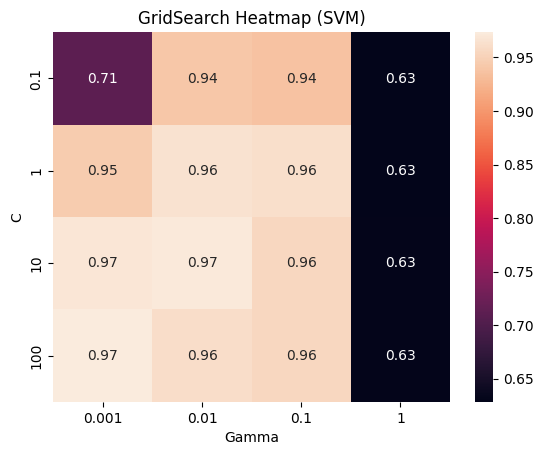


Best SVM Model Performance:
Accuracy: 0.9824561403508771
F1 Score: 0.9761904761904762
AUC: 0.99737962659679

✅ Model saved as svm_model.pkl
✅ Scaler saved as scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ================================
# LOAD DATA
# ================================
data = pd.read_csv("breast_cancer_dataset.csv")

# ================================
# CLEAN DATA
# ================================
data = data.drop(columns=["id", "Unnamed: 32"])

# ================================
# TARGET ENCODING
# ================================
data["diagnosis"] = data["diagnosis"].map({"M":1, "B":0})

# ================================
# SPLIT FEATURES & TARGET
# ================================
X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# FEATURE SCALING (IMPORTANT FOR SVM)
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 1️⃣ SVM KERNELS COMPARISON
# ================================
kernels = {
    "Linear": SVC(kernel="linear", probability=True),
    "Poly2": SVC(kernel="poly", degree=2, probability=True),
    "Poly3": SVC(kernel="poly", degree=3, probability=True),
    "RBF": SVC(kernel="rbf", probability=True)
}

results = []

for name, model in kernels.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, f1, auc])

# ================================
# RESULTS TABLE
# ================================
results_df = pd.DataFrame(results, columns=["Kernel","Accuracy","F1","AUC"])
print("\nKernel Comparison:")
print(results_df)

# ================================
# 2️⃣ GRID SEARCH (RBF BEST TUNING)
# ================================
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(SVC(kernel="rbf", probability=True),
                    param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)

# ================================
# HEATMAP (C vs gamma)
# ================================
scores = grid.cv_results_["mean_test_score"]
scores = scores.reshape(len(param_grid["C"]), len(param_grid["gamma"]))

sns.heatmap(scores,
            xticklabels=param_grid["gamma"],
            yticklabels=param_grid["C"],
            annot=True)

plt.xlabel("Gamma")
plt.ylabel("C")
plt.title("GridSearch Heatmap (SVM)")
plt.show()

# ================================
# FINAL BEST MODEL EVALUATION
# ================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("\nBest SVM Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

# ================================
# 3️⃣ SAVE MODEL (IMPORTANT 🔥)
# ================================
joblib.dump(best_model, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n✅ Model saved as svm_model.pkl")
print("✅ Scaler saved as scaler.pkl")

# ================================
# DOWNLOAD FILES (COLAB)
# ================================
from google.colab import files
files.download("svm_model.pkl")
files.download("scaler.pkl")